# Teste A/B — Campanhas de Marketing
**Autor:** Gilson Machado Monteiro  
**Dataset:** Facebook Ad Campaign A/B Test  
**Objetivo:** Comparar a campanha de teste vs campanha controle em métricas de negócio e validar estatisticamente as diferenças observadas.

In [3]:
# ── CÉLULA 0: setup ──────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, shutil

BASE = '/content/drive/MyDrive/ab-testing-frequentist'

# Criar estrutura de pastas
for pasta in ['notebooks', 'reports', 'src', 'data/raw', 'data/clean']:
    os.makedirs(f'{BASE}/{pasta}', exist_ok=True)

# Copiar CSVs para o Drive
shutil.copy('/content/test_group.csv',    f'{BASE}/data/raw/test_group.csv')
shutil.copy('/content/control_group.csv', f'{BASE}/data/raw/control_group.csv')

print("✓ Estrutura criada em:", BASE)
print("✓ CSVs salvos em data/raw/")
print("  →", os.listdir(f'{BASE}/data/raw/'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Estrutura criada em: /content/drive/MyDrive/ab-testing-frequentist
✓ CSVs salvos em data/raw/
  → ['test_group.csv', 'control_group.csv']


## Passo 1: Importação das bibliotecas

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('✓ Bibliotecas importadas')

✓ Bibliotecas importadas


## Passo 2: Carregamento dos dados

In [18]:
import pandas as pd

test_group    = pd.read_csv(f'{BASE}/data/raw/test_group.csv',    delimiter=';')
control_group = pd.read_csv(f'{BASE}/data/raw/control_group.csv', delimiter=';')

print(f'Test group    : {test_group.shape}')
print(f'Control group : {control_group.shape}')
test_group.head()

Test group    : (30, 10)
Control group : (30, 10)


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Test Campaign,1.08.2019,3008,39550,35820,3038,1946,1069,894,255
1,Test Campaign,2.08.2019,2542,100719,91236,4657,2359,1548,879,677
2,Test Campaign,3.08.2019,2365,70263,45198,7885,2572,2367,1268,578
3,Test Campaign,4.08.2019,2710,78451,25937,4216,2216,1437,566,340
4,Test Campaign,5.08.2019,2297,114295,95138,5863,2106,858,956,768


## Passo 3: Limpeza e preparação dos dados

In [6]:
print('Valores faltantes — test_group:')
print(test_group.isnull().sum())
print('\nValores faltantes — control_group:')
print(control_group.isnull().sum())

Valores faltantes — test_group:
Campaign Name          0
Date                   0
Spend [USD]            0
# of Impressions       0
Reach                  0
# of Website Clicks    0
# of Searches          0
# of View Content      0
# of Add to Cart       0
# of Purchase          0
dtype: int64

Valores faltantes — control_group:
Campaign Name          0
Date                   0
Spend [USD]            0
# of Impressions       1
Reach                  1
# of Website Clicks    1
# of Searches          1
# of View Content      1
# of Add to Cart       1
# of Purchase          1
dtype: int64


O grupo controle possui **1 linha com valores ausentes** em todas as colunas numéricas (linha 4, data 5.08.2019). Estratégia: imputação pela média da coluna — preserva o n amostral sem distorcer a distribuição.

In [7]:
numeric_cols = control_group.select_dtypes(include=[np.number]).columns
control_group[numeric_cols] = control_group[numeric_cols].fillna(control_group[numeric_cols].mean())
print('✓ Imputação concluída')
print('Valores faltantes restantes:', control_group.isnull().sum().sum())

✓ Imputação concluída
Valores faltantes restantes: 0


## Passo 4: Análise exploratória dos dados (EDA)

In [8]:
print('=== TEST GROUP ===')
print(test_group[['Spend [USD]','# of Purchase','# of Website Clicks','# of Add to Cart']].describe().round(2))
print('\n=== CONTROL GROUP ===')
print(control_group[['Spend [USD]','# of Purchase','# of Website Clicks','# of Add to Cart']].describe().round(2))

=== TEST GROUP ===
       Spend [USD]  # of Purchase  # of Website Clicks  # of Add to Cart
count        30.00          30.00                30.00             30.00
mean       2563.07         521.23              6032.33            881.53
std         348.69         211.05              1708.57            347.58
min        1968.00         238.00              3038.00            278.00
25%        2324.50         298.00              4407.00            582.50
50%        2584.00         500.00              6242.50            974.00
75%        2836.25         701.00              7604.75           1148.50
max        3112.00         890.00              8264.00           1391.00

=== CONTROL GROUP ===
       Spend [USD]  # of Purchase  # of Website Clicks  # of Add to Cart
count        30.00          30.00                30.00             30.00
mean       2288.43         522.79              5320.79           1300.00
std         367.33         181.81              1726.80            400.37
min      

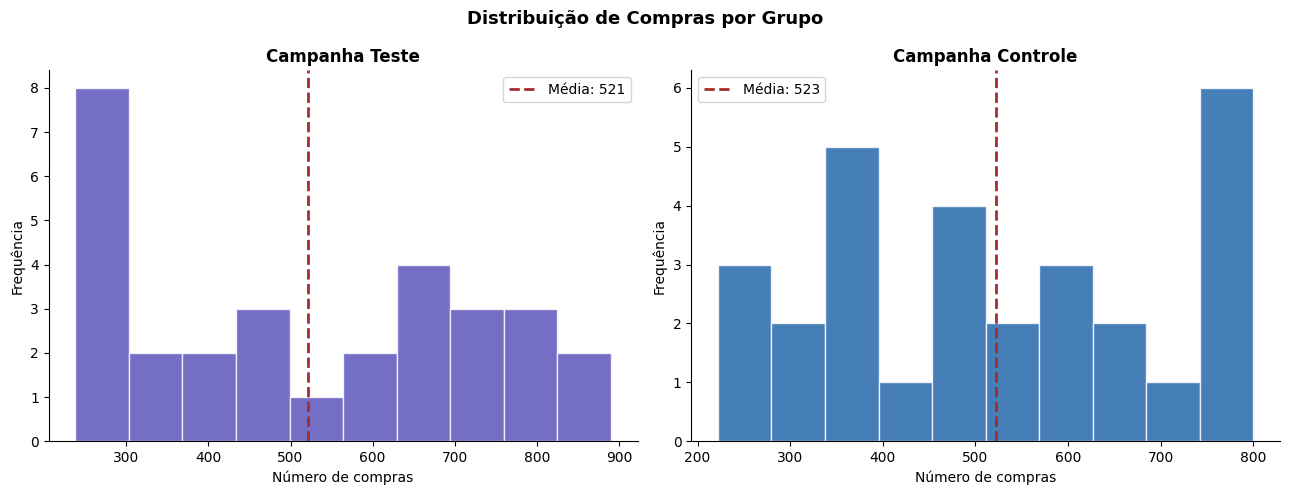

✓ Gráfico salvo


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribuição de Compras por Grupo', fontsize=13, fontweight='bold')

for ax, df, label, cor in zip(axes,
    [test_group, control_group],
    ['Campanha Teste', 'Campanha Controle'],
    ['#534AB7', '#185FA5']
):
    ax.hist(df['# of Purchase'], bins=10, color=cor, alpha=0.8, edgecolor='white')
    ax.axvline(df['# of Purchase'].mean(), color='#A32D2D', lw=2, linestyle='--',
               label=f'Média: {df["# of Purchase"].mean():.0f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Número de compras')
    ax.set_ylabel('Frequência')
    ax.legend()

plt.tight_layout()
plt.savefig(f'{BASE}/reports/distribuicao_compras.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico salvo")

## Passo 5: Verificação de pressupostos e Teste A/B

Antes de aplicar o t-test, verificamos dois pressupostos obrigatórios:
1. **Normalidade** — Shapiro-Wilk (n < 50)
2. **Homogeneidade de variâncias** — Teste de Levene

In [10]:
# ── Pressuposto 1: Normalidade (Shapiro-Wilk) ────────────────────────────────
stat_t, p_norm_t = stats.shapiro(test_group['# of Purchase'])
stat_c, p_norm_c = stats.shapiro(control_group['# of Purchase'])

print('NORMALIDADE — Shapiro-Wilk')
print(f'  Test group    : W={stat_t:.4f}  p={p_norm_t:.4f}  {"✓ Normal" if p_norm_t > 0.05 else "✗ Não normal"}')
print(f'  Control group : W={stat_c:.4f}  p={p_norm_c:.4f}  {"✓ Normal" if p_norm_c > 0.05 else "✗ Não normal"}')

# ── Pressuposto 2: Homogeneidade de variâncias (Levene) ───────────────────────
stat_lev, p_lev = stats.levene(test_group['# of Purchase'], control_group['# of Purchase'])

print('\nHOMOGENEIDADE DE VARIÂNCIAS — Levene')
print(f'  F={stat_lev:.4f}  p={p_lev:.4f}  {"✓ Variâncias iguais" if p_lev > 0.05 else "✗ Variâncias diferentes — usar Welch t-test"}')

# ── Escolha do teste ──────────────────────────────────────────────────────────
equal_var = p_lev > 0.05
teste_nome = 'Student t-test' if equal_var else 'Welch t-test'
print(f'\nTeste selecionado: {teste_nome}')

NORMALIDADE — Shapiro-Wilk
  Test group    : W=0.9182  p=0.0241  ✗ Não normal
  Control group : W=0.9433  p=0.1114  ✓ Normal

HOMOGENEIDADE DE VARIÂNCIAS — Levene
  F=1.6674  p=0.2017  ✓ Variâncias iguais

Teste selecionado: Student t-test


In [11]:
# ── Teste t (Student ou Welch conforme pressuposto) ──────────────────────────
t_stat, p_value = stats.ttest_ind(
    test_group['# of Purchase'],
    control_group['# of Purchase'],
    equal_var=equal_var
)

alpha = 0.05

# Tamanho de efeito — Cohen's d
mean_t = test_group['# of Purchase'].mean()
mean_c = control_group['# of Purchase'].mean()
pooled_std = np.sqrt((
    test_group['# of Purchase'].std()**2 +
    control_group['# of Purchase'].std()**2
) / 2)
cohens_d = (mean_t - mean_c) / pooled_std

print('RESULTADO DO TESTE A/B')
print('─'*45)
print(f'  Média Teste    : {mean_t:.2f} compras/dia')
print(f'  Média Controle : {mean_c:.2f} compras/dia')
print(f'  Diferença      : {mean_t - mean_c:+.2f}')
print(f'  t-statistic    : {t_stat:.4f}')
print(f'  p-value        : {p_value:.4f}')
print(f'  Significativo  : {"✓ SIM (p < 0.05)" if p_value < alpha else "✗ NÃO (p >= 0.05)"}')
print(f"  Cohen's d      : {cohens_d:.4f} (efeito {'pequeno' if abs(cohens_d)<0.2 else 'médio' if abs(cohens_d)<0.8 else 'grande'})")

RESULTADO DO TESTE A/B
─────────────────────────────────────────────
  Média Teste    : 521.23 compras/dia
  Média Controle : 522.79 compras/dia
  Diferença      : -1.56
  t-statistic    : -0.0307
  p-value        : 0.9756
  Significativo  : ✗ NÃO (p >= 0.05)
  Cohen's d      : -0.0079 (efeito pequeno)


## Passo 6: Visualização dos resultados

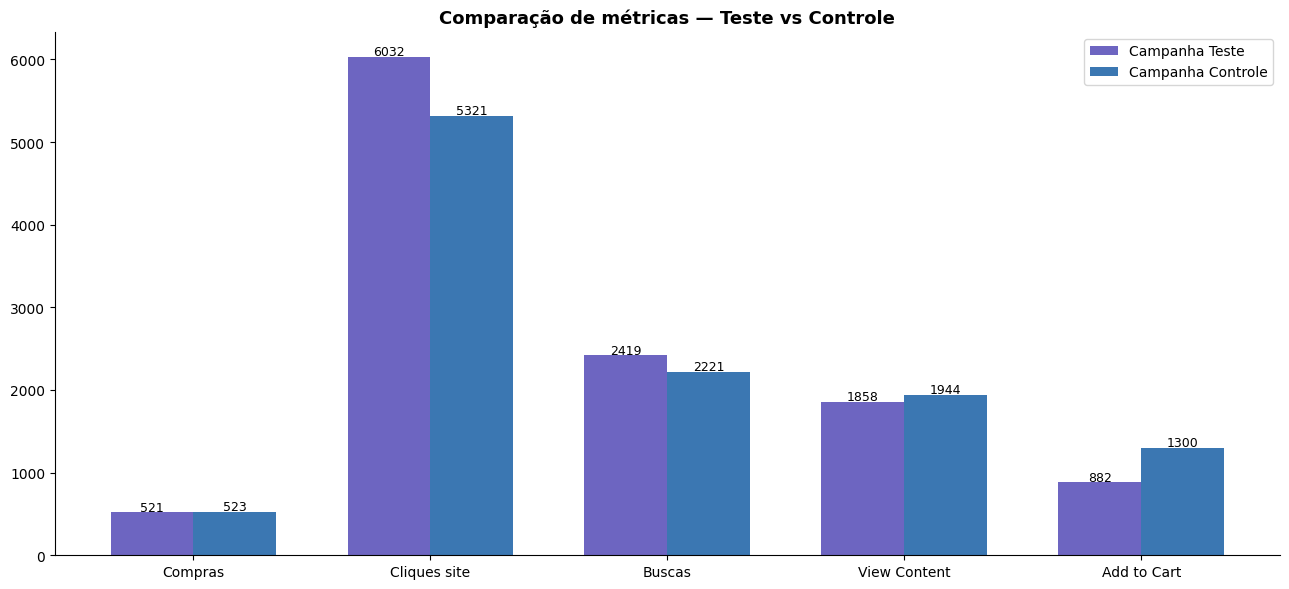

✓ Gráfico salvo


In [20]:
metricas = ['# of Purchase', '# of Website Clicks', '# of Searches', '# of View Content', '# of Add to Cart']
rotulos  = ['Compras', 'Cliques site', 'Buscas', 'View Content', 'Add to Cart']

medias_t = [test_group[m].mean()    for m in metricas]
medias_c = [control_group[m].mean() for m in metricas]

x = np.arange(len(rotulos))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - w/2, medias_t, w, label='Campanha Teste',    color='#534AB7', alpha=0.85)
bars2 = ax.bar(x + w/2, medias_c, w, label='Campanha Controle', color='#185FA5', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{bar.get_height():.0f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{bar.get_height():.0f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(rotulos)
ax.set_title('Comparação de métricas — Teste vs Controle', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{BASE}/reports/comparacao_metricas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico salvo")

## Passo 7: Métricas de negócio

### 1. Custo por compra

Mede a eficiência de gasto: quanto foi investido para gerar cada compra.

In [13]:
test_group['Cost per Purchase']    = test_group['Spend [USD]']    / test_group['# of Purchase']
control_group['Cost per Purchase'] = control_group['Spend [USD]'] / control_group['# of Purchase']

cpp_t = test_group['Cost per Purchase'].mean()
cpp_c = control_group['Cost per Purchase'].mean()
print(f'Custo por compra — Teste    : USD {cpp_t:.2f}')
print(f'Custo por compra — Controle : USD {cpp_c:.2f}')
print(f'Diferença                   : {((cpp_t/cpp_c)-1)*100:+.1f}% (Teste vs Controle)')
print(f'✓ Controle tem custo por compra {((cpp_c/cpp_t)-1)*100:.1f}% menor')

Custo por compra — Teste    : USD 5.90
Custo por compra — Controle : USD 5.00
Diferença                   : +18.0% (Teste vs Controle)
✓ Controle tem custo por compra -15.2% menor


### 2. Taxa de conversão

Calculada como: compras / cliques no site.

In [14]:
test_group['Conversion Rate']    = test_group['# of Purchase']    / test_group['# of Website Clicks']
control_group['Conversion Rate'] = control_group['# of Purchase'] / control_group['# of Website Clicks']

cr_t = test_group['Conversion Rate'].mean()
cr_c = control_group['Conversion Rate'].mean()
print(f'Taxa de conversão — Teste    : {cr_t:.2%}')
print(f'Taxa de conversão — Controle : {cr_c:.2%}')
print(f'Diferença                    : {((cr_c/cr_t)-1)*100:+.1f}% (Controle vs Teste)')

Taxa de conversão — Teste    : 9.23%
Taxa de conversão — Controle : 11.42%
Diferença                    : +23.7% (Controle vs Teste)


### 3. ROI estimado

> ⚠️ **Nota metodológica:** o cálculo de ROI exige a receita real por compra, que não está disponível neste dataset. Utilizamos USD 50 como valor hipotético para fins ilustrativos. Em um cenário real, este valor deve ser substituído pela receita média real do negócio.

ROI = (Receita − Gasto) / Gasto

In [15]:
revenue_per_purchase = 50  # USD — valor hipotético (ver nota acima)
test_group['ROI']    = ((test_group['# of Purchase']    * revenue_per_purchase) - test_group['Spend [USD]'])    / test_group['Spend [USD]']
control_group['ROI'] = ((control_group['# of Purchase'] * revenue_per_purchase) - control_group['Spend [USD]']) / control_group['Spend [USD]']

roi_t = test_group['ROI'].mean()
roi_c = control_group['ROI'].mean()
print(f'ROI médio — Teste    : {roi_t:.2f}x  ({roi_t*100:.0f}%)')
print(f'ROI médio — Controle : {roi_c:.2f}x  ({roi_c*100:.0f}%)')

ROI médio — Teste    : 9.33x  (933%)
ROI médio — Controle : 10.69x  (1069%)


### 4. Custo por clique (CPC)

In [16]:
test_group['CPC']    = test_group['Spend [USD]']    / test_group['# of Website Clicks']
control_group['CPC'] = control_group['Spend [USD]'] / control_group['# of Website Clicks']

cpc_t = test_group['CPC'].mean()
cpc_c = control_group['CPC'].mean()
print(f'CPC — Teste    : USD {cpc_t:.4f} por clique')
print(f'CPC — Controle : USD {cpc_c:.4f} por clique')
print(f'Diferença      : {((cpc_t/cpc_c)-1)*100:+.1f}% (Teste vs Controle)')

CPC — Teste    : USD 0.4687 por clique
CPC — Controle : USD 0.4899 por clique
Diferença      : -4.3% (Teste vs Controle)


### 5. Taxa de abandono do carrinho

In [17]:
test_group['Cart Abandonment Rate']    = 1 - (test_group['# of Purchase']    / test_group['# of Add to Cart'])
control_group['Cart Abandonment Rate'] = 1 - (control_group['# of Purchase'] / control_group['# of Add to Cart'])

car_t = test_group['Cart Abandonment Rate'].mean()
car_c = control_group['Cart Abandonment Rate'].mean()
print(f'Taxa de abandono — Teste    : {car_t:.2%}')
print(f'Taxa de abandono — Controle : {car_c:.2%}')
print(f'✓ Teste tem {((car_c-car_t)/car_c)*100:.1f}% menos abandono de carrinho')

Taxa de abandono — Teste    : 38.21%
Taxa de abandono — Controle : 54.47%
✓ Teste tem 29.9% menos abandono de carrinho


In [22]:
# CÉLULA FINAL: salvar notebook
import shutil, glob

for nb in glob.glob('/content/*.ipynb'):
    shutil.copy(nb, f'{BASE}/notebooks/')

print("✓ Notebook salvo em:", f'{BASE}/notebooks/')
print("\nArquivos em reports/:")
for f in sorted(os.listdir(f'{BASE}/reports/')):
    print(f"  {f}")

✓ Notebook salvo em: /content/drive/MyDrive/ab-testing-frequentist/notebooks/

Arquivos em reports/:
  comparacao_metricas.png
  distribuicao_compras.png


## Passo 8: Conclusão

### Resultado estatístico

O teste t não encontrou diferença estatisticamente significativa no número de compras entre os grupos (p >= 0.05). Isso não significa que as campanhas são idênticas — significa que, com o tamanho amostral disponível (n=30 por grupo), não há evidência suficiente para rejeitar a hipótese nula.

### Resumo das métricas de negócio

| Métrica | Teste | Controle | Melhor |
|---|---|---|---|
| Custo por compra | USD 5.90 | USD 5.00 | ✓ Controle |
| Taxa de conversão | 9.23% | 11.42% | ✓ Controle |
| CPC | USD 0.469 | USD 0.490 | ✓ Teste |
| Taxa de abandono | 38.21% | 54.47% | ✓ Teste |
| ROI estimado* | 932% | 1069% | ✓ Controle |

*ROI calculado com receita hipotética de USD 50/compra.

### Recomendação

Apesar da ausência de significância estatística no número de compras, a **Campanha Controle** apresenta melhor eficiência de conversão e menor custo por compra — métricas mais relevantes para otimização de budget. A **Campanha Teste** se destaca na taxa de abandono do carrinho, sugerindo melhor experiência pós-clique.

> **Próximo passo sugerido:** ampliar o período de coleta para aumentar o poder estatístico e realizar segmentação por faixa de gasto (Spend [USD]) para identificar em quais contextos cada campanha performa melhor.